<a href="https://colab.research.google.com/github/abiud2emiliano-sudo/PPIA/blob/main/acf3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ACTIVIDAD FUNDAMENTAL 3 / ARBOL DE DECISION


In [1]:
# Importar librerías
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/refs/heads/master/dataset.csv"

df = pd.read_csv(url)

# Mostrar las primeras filas
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(303, 14)


In [3]:
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


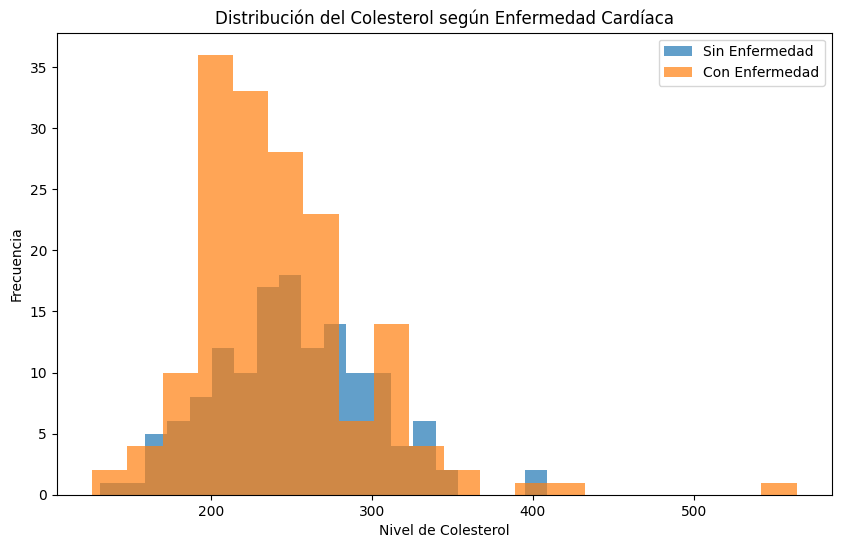

In [5]:
# Importar librerías para visualización
import matplotlib.pyplot as plt

# Histograma del colesterol segmentado por enfermedad cardíaca
plt.figure(figsize=(10,6))

# Personas sin enfermedad cardíaca
plt.hist(df[df['target'] == 0]['chol'],
         bins=20,
         alpha=0.7,
         label='Sin Enfermedad')

# Personas con enfermedad cardíaca
plt.hist(df[df['target'] == 1]['chol'],
         bins=20,
         alpha=0.7,
         label='Con Enfermedad')

# Configuración del gráfico
plt.title('Distribución del Colesterol según Enfermedad Cardíaca')
plt.xlabel('Nivel de Colesterol')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

In [6]:
# Importar herramientas necesarias
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar atributos (X) y etiquetas (y)
X = df.drop('target', axis=1)
y = df['target']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Escalado de datos
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Verificar dimensiones
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (242, 13)
X_test: (61, 13)


In [7]:
# Importar modelo
from sklearn.tree import DecisionTreeClassifier

# Crear el modelo
modelo = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# Entrenar modelo
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [8]:
predicciones = modelo.predict(X_test[:3])

print("Predicciones:")
print(predicciones)

print("\nValores reales:")
print(y_test.iloc[:3].values)

Predicciones:
[0 1 1]

Valores reales:
[0 0 1]


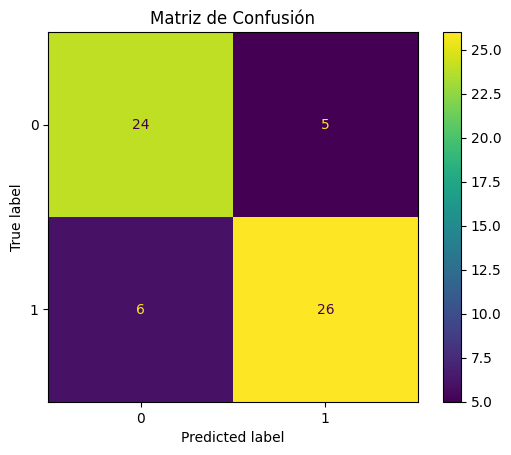

In [9]:
# Importar métricas
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Predicciones completas
y_pred = modelo.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Matriz de Confusión")
plt.show()

In [10]:
print("Reporte de Clasificación:\n")

print(classification_report(y_test, y_pred))

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

